# Production Planning

Convert demand and inventory requirements into weekly plant allocations while minimizing production and transport cost under capacity and capability constraints.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
requirements = pd.read_csv(PROJECT_ROOT / "data/processed/production_requirements.csv", parse_dates=["week_start"])
production_plan = pd.read_csv(PROJECT_ROOT / "data/processed/production_plan.csv", parse_dates=["week_start"])
display(requirements.head(20))
display(production_plan.head(20))

,week_start,sku,region,forecast_cases,target_inventory_cases,opening_inventory_cases,required_production_cases
0,2025-06-30,BB1000,Central,269.540710,655.083333,524.066667,400.557377
1,2025-06-30,BB1000,East,302.879770,592.750000,474.200000,421.429770
2,2025-06-30,BB1000,North,327.180338,691.333333,553.066667,465.447005
3,2025-06-30,BB1000,South,339.180454,900.333333,720.266667,519.247121
4,2025-06-30,BB1000,West,371.780983,892.500000,714.000000,550.280983
5,2025-06-30,BB250,Central,150.164894,371.875000,297.500000,224.539894
6,2025-06-30,BB250,East,164.458781,346.583333,277.266667,233.775448
7,2025-06-30,BB250,North,171.717079,376.333333,301.066667,246.983746
8,2025-06-30,BB250,South,197.623967,506.791667,405.433333,298.982301
9,2025-06-30,BB250,West,211.246058,505.125000,404.100000,312.271058


,plant_id,sku,region,production_cases,total_cost,week_start
0,P01,BB250,North,246.98375,4939.67500,2025-06-30
1,P01,BB500,North,368.87505,9959.62635,2025-06-30
2,P01,BB1000,North,465.44701,19083.32741,2025-06-30
3,P01,LM250,North,186.19101,3537.62919,2025-06-30
4,P01,LM500,North,295.04082,7376.02050,2025-06-30
5,P01,OR500,North,235.00590,6110.15340,2025-06-30
6,P01,OR1000,North,329.98420,13199.36800,2025-06-30
7,P01,EN250,North,148.47822,5493.69414,2025-06-30
8,P01,EN500,North,116.78360,6656.66520,2025-06-30
9,P01,WT1000,North,733.57511,11737.20176,2025-06-30


,week_start,plant_id,production_cases,weekly_capacity_cases,capacity_utilization
0,2025-06-30,P01,3126.36467,180000,1.74
1,2025-06-30,P02,10225.89383,220000,4.65
2,2025-06-30,P03,2913.93270,160000,1.82
3,2025-07-07,P01,3526.30361,180000,1.96
4,2025-07-07,P02,11371.69045,220000,5.17
5,2025-07-07,P03,3312.12259,160000,2.07
6,2025-07-14,P01,3547.88559,180000,1.97
7,2025-07-14,P02,11425.37187,220000,5.19
8,2025-07-14,P03,3350.67932,160000,2.09
9,2025-07-21,P01,3511.77226,180000,1.95


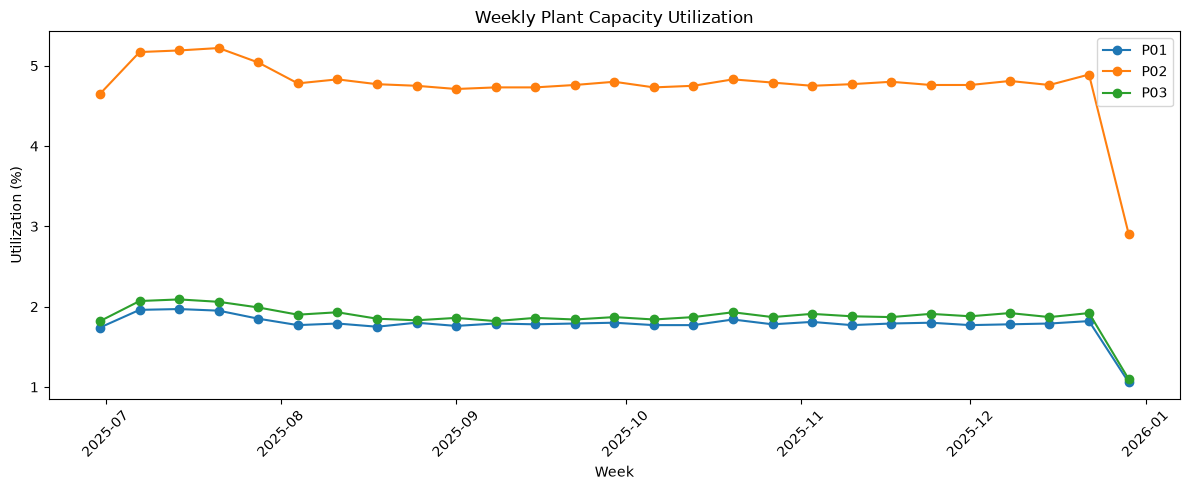

In [3]:
utilization = pd.read_csv(PROJECT_ROOT / "data/processed/plant_production_utilization.csv", parse_dates=["week_start"])
display(utilization.head(20))
plt.figure(figsize=(12, 5))
for plant, group in utilization.groupby("plant_id"):
    plt.plot(group["week_start"], group["capacity_utilization"], marker="o", label=plant)
plt.title("Weekly Plant Capacity Utilization")
plt.ylabel("Utilization (%)")
plt.xlabel("Week")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

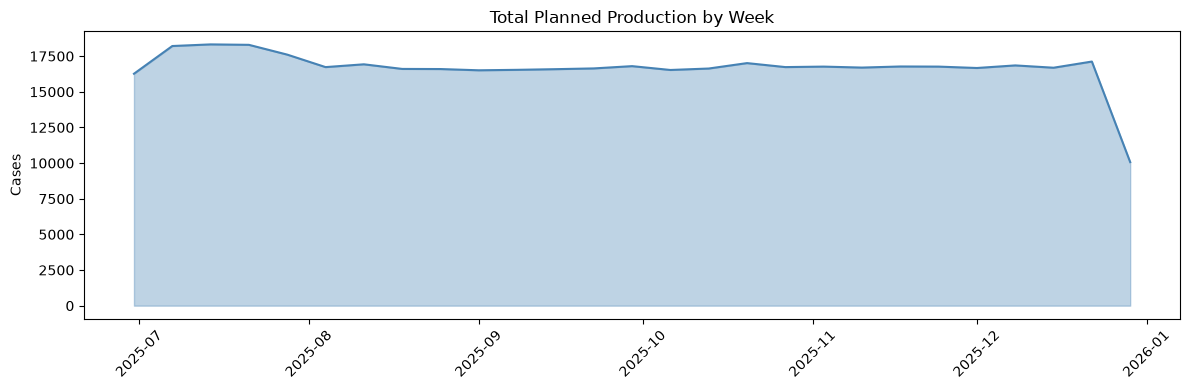

In [4]:
weekly = production_plan.groupby("week_start", as_index=False)["production_cases"].sum()
plt.figure(figsize=(12, 4))
plt.fill_between(weekly["week_start"], weekly["production_cases"], alpha=0.35, color="steelblue")
plt.plot(weekly["week_start"], weekly["production_cases"], color="steelblue")
plt.title("Total Planned Production by Week")
plt.ylabel("Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()